# Lab 11

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense

### XOR dataset

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

---

## Part A: Only SGD

### Create the model

In [ ]:
learning_rate = 0.1


def build_model(lr, momentum=0.0):
    model = keras.Sequential(
        [
            Dense(8, input_dim=2, activation="relu"),
            Dense(1, activation="sigmoid"),
        ]
    )
    optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    model.compile(optimizer=optimizer, loss="mse")
    return model


model = build_model(learning_rate)

### Callback and Training loop

In [11]:
class LearningRateCallback(keras.callbacks.Callback):
    def __init__(self, learning_rates_list):
        super().__init__()
        self.learning_rates_list = learning_rates_list

    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        self.learning_rates_list.append(lr)

In [12]:
converged = False
target_loss = 0.001
losses = []
learning_rates = []
total_epochs = 0

lr_callback = LearningRateCallback(learning_rates)

while not converged:
    history = model.fit(X, y, epochs=10, verbose=0, callbacks=[lr_callback])
    loss = history.history["loss"][0]
    losses.append(loss)
    total_epochs += 10

    if loss <= target_loss:
        converged = True

print(f"Converged at epoch: {total_epochs}")

Converged at epoch: 6490


### Plots

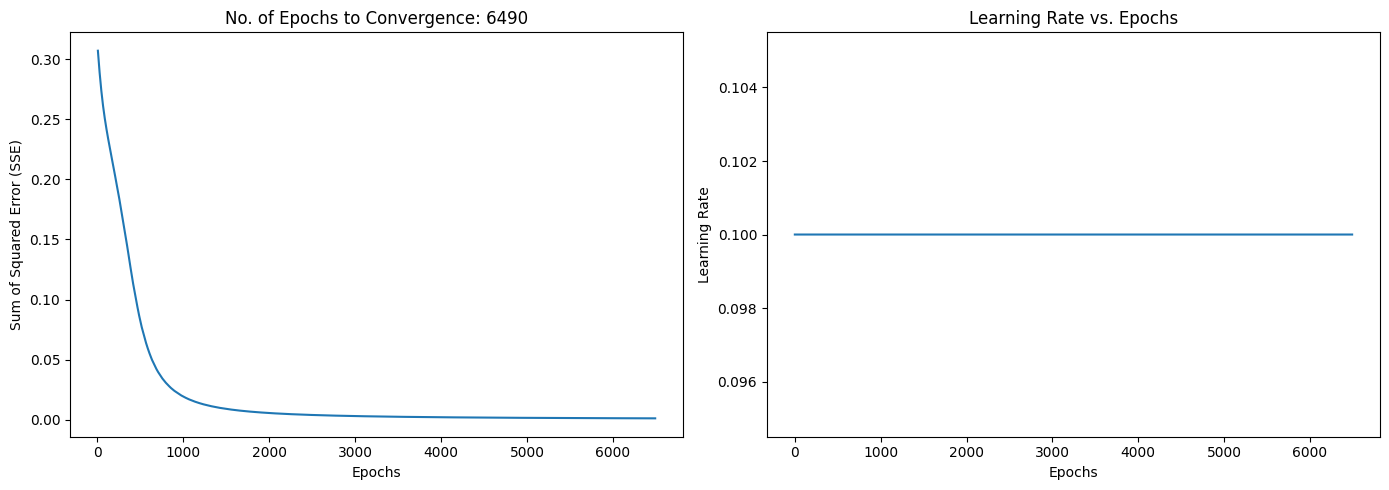

In [13]:
epoch_axis_sse = list(range(10, total_epochs + 1, 10))
epoch_axis_lr = list(range(1, len(learning_rates) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SSE vs Epochs
axes[0].plot(epoch_axis_sse, losses)
axes[0].set_title(f"No. of Epochs to Convergence: {total_epochs}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Sum of Squared Error (SSE)")

# Learning Rate vs Epochs
axes[1].plot(epoch_axis_lr, learning_rates)
axes[1].set_title("Learning Rate vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

---

## Part B: SGD with Momentum

In [14]:
model_mom = build_model(lr=0.1, momentum=0.9)

converged_mom = False
losses_mom = []
learning_rates_mom = []
total_epochs_mom = 0

lr_callback_mom = LearningRateCallback(learning_rates_mom)

while not converged_mom:
    history = model_mom.fit(X, y, epochs=10, verbose=0, callbacks=[lr_callback_mom])
    loss = history.history["loss"][0]
    losses_mom.append(loss)
    total_epochs_mom += 10

    if loss <= target_loss:
        converged_mom = True

print(f"Converged at epoch: {total_epochs_mom}")

Converged at epoch: 580


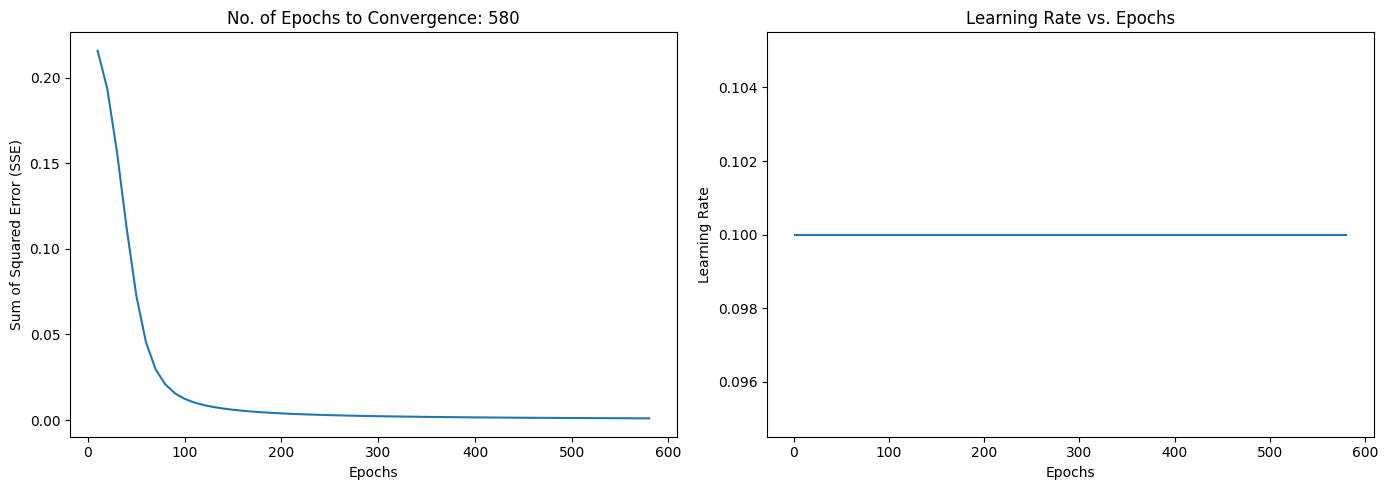

In [15]:
epoch_axis_sse_mom = list(range(10, total_epochs_mom + 1, 10))
epoch_axis_lr_mom = list(range(1, len(learning_rates_mom) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SSE vs Epochs
axes[0].plot(epoch_axis_sse_mom, losses_mom)
axes[0].set_title(f"No. of Epochs to Convergence: {total_epochs_mom}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Sum of Squared Error (SSE)")

# Learning Rate vs Epochs
axes[1].plot(epoch_axis_lr_mom, learning_rates_mom)
axes[1].set_title("Learning Rate vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

---

## Part C: Adaptive Learning Rate

In [16]:
lr_adaptive = 0.1
model_adp = build_model(lr=lr_adaptive, momentum=0.0)

converged_adp = False
losses_adp = []
learning_rates_adp = []
total_epochs_adp = 0
prev_loss = None

while not converged_adp:
    history = model_adp.fit(X, y, epochs=5, verbose=0)
    loss = history.history["loss"][-1]
    losses_adp.append(loss)
    total_epochs_adp += 5
    learning_rates_adp.append(lr_adaptive)

    if prev_loss is not None:
        if loss > prev_loss * 1.04:
            lr_adaptive *= 0.7
        elif loss < prev_loss:
            lr_adaptive *= 1.05
        weights = model_adp.get_weights()
        model_adp = build_model(lr=lr_adaptive, momentum=0.0)
        model_adp.set_weights(weights)

    prev_loss = loss

    if loss <= target_loss:
        converged_adp = True

print(f"Converged at epoch: {total_epochs_adp}")

Converged at epoch: 435


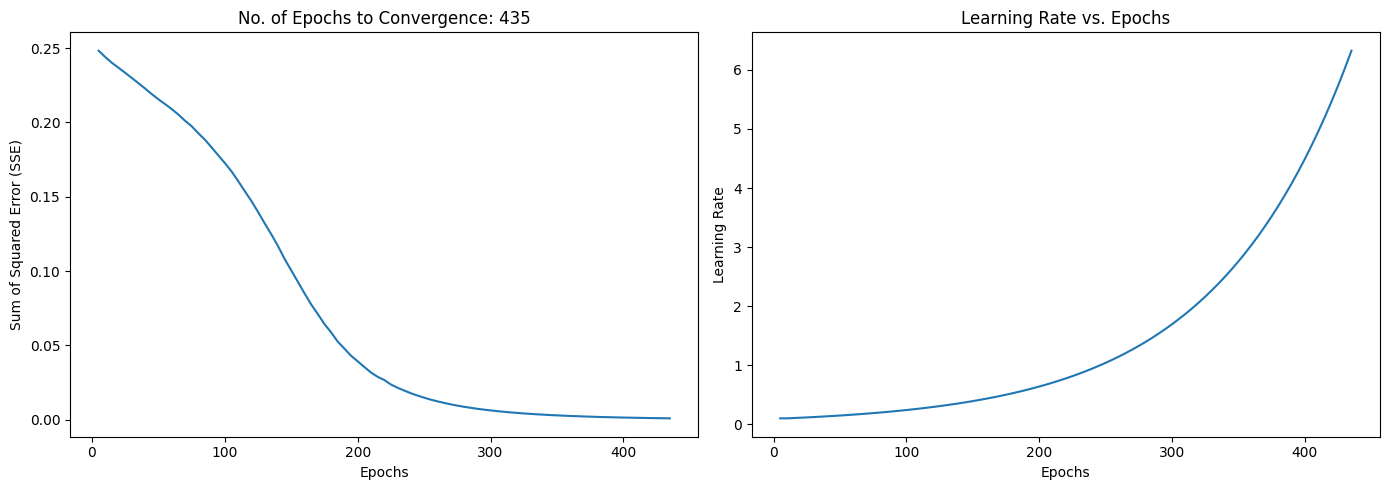

In [17]:
epoch_axis_sse_adp = list(range(5, total_epochs_adp + 1, 5))
epoch_axis_lr_adp = list(range(5, total_epochs_adp + 1, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SSE vs Epochs
axes[0].plot(epoch_axis_sse_adp, losses_adp)
axes[0].set_title(f"No. of Epochs to Convergence: {total_epochs_adp}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Sum of Squared Error (SSE)")

# Learning Rate vs Epochs
axes[1].plot(epoch_axis_lr_adp, learning_rates_adp)
axes[1].set_title("Learning Rate vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

---

## Part D: Adaptive Learning Rate + Momentum

In [18]:
lr_adp_mom = 0.1
model_adp_mom = build_model(lr=lr_adp_mom, momentum=0.9)

converged_adp_mom = False
losses_adp_mom = []
learning_rates_adp_mom = []
total_epochs_adp_mom = 0
prev_loss_mom = None

while not converged_adp_mom:
    history = model_adp_mom.fit(X, y, epochs=5, verbose=0)
    loss = history.history["loss"][-1]
    losses_adp_mom.append(loss)
    total_epochs_adp_mom += 5
    learning_rates_adp_mom.append(lr_adp_mom)

    if prev_loss_mom is not None:
        if loss > prev_loss_mom * 1.04:
            lr_adp_mom *= 0.7
        elif loss < prev_loss_mom:
            lr_adp_mom *= 1.05
        weights = model_adp_mom.get_weights()
        model_adp_mom = build_model(lr=lr_adp_mom, momentum=0.9)
        model_adp_mom.set_weights(weights)

    prev_loss_mom = loss

    if loss <= target_loss:
        converged_adp_mom = True

print(f"Converged at epoch: {total_epochs_adp_mom}")

Converged at epoch: 345


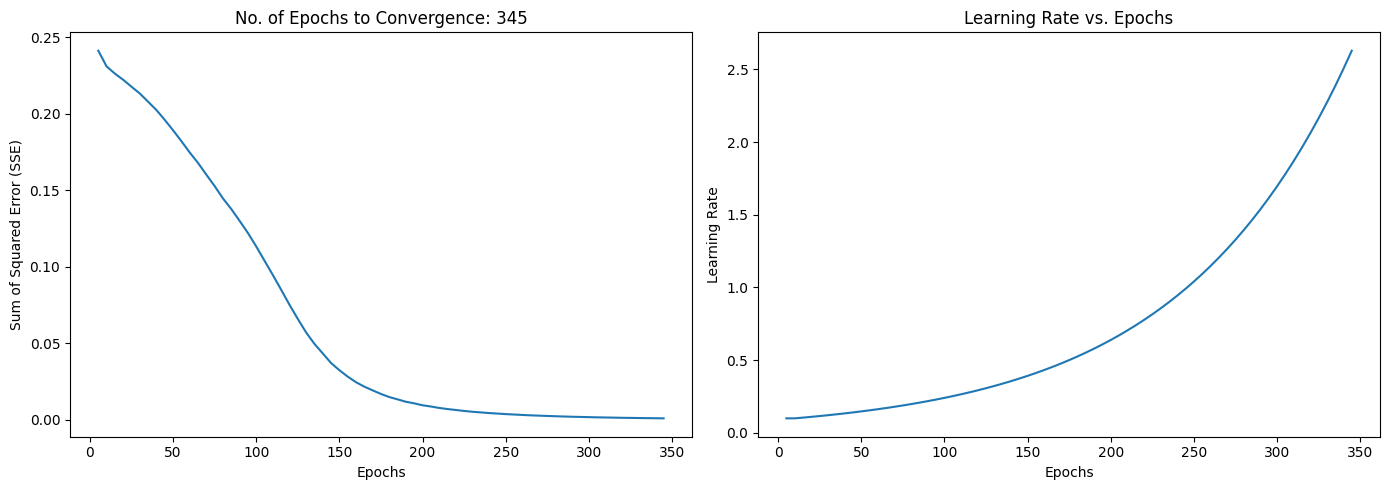

In [19]:
epoch_axis_sse_adp_mom = list(range(5, total_epochs_adp_mom + 1, 5))
epoch_axis_lr_adp_mom = list(range(5, total_epochs_adp_mom + 1, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SSE vs Epochs
axes[0].plot(epoch_axis_sse_adp_mom, losses_adp_mom)
axes[0].set_title(f"No. of Epochs to Convergence: {total_epochs_adp_mom}")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Sum of Squared Error (SSE)")

# Learning Rate vs Epochs
axes[1].plot(epoch_axis_lr_adp_mom, learning_rates_adp_mom)
axes[1].set_title("Learning Rate vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

---
## 2. Report

### Q1: How does a multilayer neural network solve the XOR problem?

**Ans:** A multilayer neural network introduces hidden layers with non linear activation functions. These layers transform the input space into a higher dimensional space where the XOR problem becomes linearly separable.

---


### Q2: In a backpropagation neural network, why are the middle layers called "hidden"?

**Ans:** They are called hidden because their outputs are not directly observed. They perform intermediate computations between input and output layers.

---


### Q3: How are hyperparameters different from model parameters?

**Ans:** Model parameters are learned during training (weights, biases), while hyperparameters (learning rate, momentum, epochs) are set before training.

---


### Q4: Explain the concept of accelerated learning in backpropagation.

**Ans:** Acceleration techniques like momentum help the model converge faster by considering past gradients and reducing oscillations.

---


### Q5: What are two heuristics applied in adaptive learning rate?

**Ans:**

- **Heuristic 1:** If error increases significantly, reduce learning rate.

- **Heuristic 2:** If error decreases, slightly increase learning rate to speed up convergence.

---
